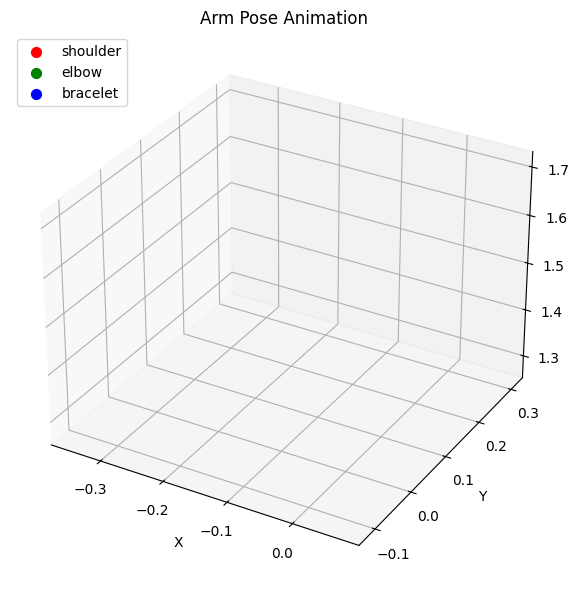

In [3]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np

# -------------------------------
# 1. Load the data from your file
# -------------------------------
file_path = "recordings/camera0_20260425_013205_poses.csv"
df = pd.read_csv(file_path)

# Make sure the joints are plotted in a fixed order
bone_order = ['shoulder', 'elbow', 'bracelet']
colors = {'shoulder': 'red', 'elbow': 'green', 'bracelet': 'blue'}

# Group data into frames (each frame has one row per joint)
frames = df['frame_idx'].unique()
frames.sort()

# Store the joint positions per frame in a dictionary for fast lookup
frame_data = {}
for frame_id in frames:
    fdf = df[df['frame_idx'] == frame_id].set_index('position_name')
    # Extract x,y,z for shoulder, elbow, bracelet (if any missing, skip frame)
    try:
        pts = fdf.loc[bone_order, ['x','y','z']].values  # shape (3,3)
        frame_data[frame_id] = pts
    except KeyError:
        continue

# Only keep frames that have all three joints
valid_frames = sorted(frame_data.keys())

# -------------------------------
# 2. Set up the 3D plot
# -------------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Determine fixed axis limits from entire dataset
all_x = df['x'].values
all_y = df['y'].values
all_z = df['z'].values
max_range = max(np.ptp(all_x), np.ptp(all_y), np.ptp(all_z)) * 0.6
mid_x = np.mean(all_x)
mid_y = np.mean(all_y)
mid_z = np.mean(all_z)
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Arm Pose Animation')

# Create empty line for the skeleton and scatter points for joints
(skeleton_line,) = ax.plot([], [], [], 'gray', linewidth=2, marker='o', markersize=5)
# Individual joint dots
joint_scatters = []
for joint, color in colors.items():
    sc = ax.scatter([], [], [], color=color, s=50, label=joint)
    joint_scatters.append(sc)

ax.legend(loc='upper left')

# -------------------------------
# 3. Animation functions
# -------------------------------
def init():
    skeleton_line.set_data([], [])
    skeleton_line.set_3d_properties([])
    for sc in joint_scatters:
        sc._offsets3d = ([], [], [])
    return [skeleton_line] + joint_scatters

def animate(i):
    frame_id = valid_frames[i]
    pts = frame_data[frame_id]  # shape (3,3)
    # Update skeleton line (connect the three points)
    skeleton_line.set_data(pts[:, 0], pts[:, 1])
    skeleton_line.set_3d_properties(pts[:, 2])
    # Update each joint's scatter
    for sc, joint in zip(joint_scatters, bone_order):
        idx = bone_order.index(joint)
        sc._offsets3d = ([pts[idx, 0]], [pts[idx, 1]], [pts[idx, 2]])
    ax.set_title(f'Frame {frame_id}')
    return [skeleton_line] + joint_scatters

# -------------------------------
# 4. Create and display animation
# -------------------------------
ani = FuncAnimation(fig, animate, frames=len(valid_frames),
                    init_func=init, interval=100, blit=False)

plt.tight_layout()
plt.show()